In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import country_converter as coco

# Data is loaded from GitHub with URL links, so the notebook runs on any computer
BASE_URL = "https://raw.githubusercontent.com/AndrewEberhardt/DataScienceProject/main/data/"

SOURCE_PS = "Source: World Bank Commodity Price Data (Pink Sheet)"
SOURCE_FAO = "Sources: FAOSTAT Producer Prices; World Bank Pink Sheet"


def add_source(fig, text):
    """Write the data source under the chart."""
    fig.text(0.01, 0.005, text, fontsize=8, color="#666666", ha="left", va="bottom")

In [2]:
xls = pd.ExcelFile(BASE_URL + "raw/crops/CMO-Historical-Data-Annual.xlsx")
print(xls.sheet_names)

['Cover', 'Annual Prices (Nominal)', 'Annual Indices (Nominal)', 'Annual Prices (Real)', 'Annual Indices (Real)', 'Description', 'Definitions', 'Index Weights']


In [3]:
df = pd.read_excel(xls, sheet_name="Annual Prices (Nominal)",  header=6, skiprows=[7], na_values="…")
df = df.rename(columns={df.columns[0]: "year"})
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"] >= 1996].reset_index(drop=True)
df.head()


,year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,1996,20.4,20.7,18.5,22.1,38.1,33.5,2.73,2.84,3.67,...,1506,30.0,2295,774,6165,7501,1025,388,397,5.2
1,1997,19.2,19.1,18.1,20.3,35.1,31.3,2.48,2.74,3.91,...,1599,30.2,2277,624,5647,6927,1316,331,395,4.9
2,1998,13.1,12.7,12.1,14.3,29.2,26.8,2.09,2.42,3.02,...,1357,31.0,1654,529,5540,4630,1024,294,372,5.6
3,1999,18.1,17.8,17.2,19.2,25.9,24.3,2.27,2.13,3.14,...,1361,27.6,1573,503,5404,6011,1076,279,377,5.2
4,2000,28.2,28.3,26.1,30.3,26.3,26.6,4.31,3.86,4.71,...,1549,28.8,1813,454,5436,8638,1128,279,545,5.0


In [4]:
df_real = pd.read_excel(xls, sheet_name="Annual Prices (Real)",  header=6, skiprows=[7], na_values="…")
df_real = df_real.rename(columns={df_real.columns[0]: "year"})
df_real["year"] = pd.to_numeric(df_real["year"], errors="coerce")
df_real = df_real[df_real["year"] >= 1996].reset_index(drop=True)
df_real.head()


,year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver,MUV Index
0,1996,22.6,22.9,20.6,24.5,42.2,37.2,3.03,3.15,4.07,...,33.3,2545,859,6837,8319,1137,430,440,5.8,90.2
1,1997,22.3,22.2,21.1,23.7,40.8,36.5,2.89,3.19,4.55,...,35.1,2650,726,6572,8062,1532,385,460,5.7,85.9
2,1998,15.9,15.5,14.8,17.5,35.6,32.7,2.54,2.94,3.67,...,37.7,2013,643,6742,5634,1247,358,453,6.8,82.2
3,1999,22.4,22.1,21.3,23.9,32.1,30.1,2.81,2.64,3.89,...,34.2,1952,624,6705,7459,1336,346,468,6.5,80.6
4,2000,35.5,35.5,32.8,38.1,33.0,33.4,5.42,4.85,5.92,...,36.2,2279,571,6832,10857,1418,351,685,6.2,79.6


In [5]:
colonnes = ["year", "Soybeans", "Soybean oil", "Soybean meal", "Palm oil", "Palm kernel oil", "Beef"]
df_sel = df[colonnes]
df_sel.head()


,year,Soybeans,Soybean oil,Soybean meal,Palm oil,Palm kernel oil,Beef
0,1996,305,552,268,531,728.0,1.75
1,1997,295,565,276,546,652.0,1.85
2,1998,243,626,170,671,687.0,1.72
3,1999,202,426,165,436,694.0,1.81
4,2000,212,338,204,310,444.0,1.93


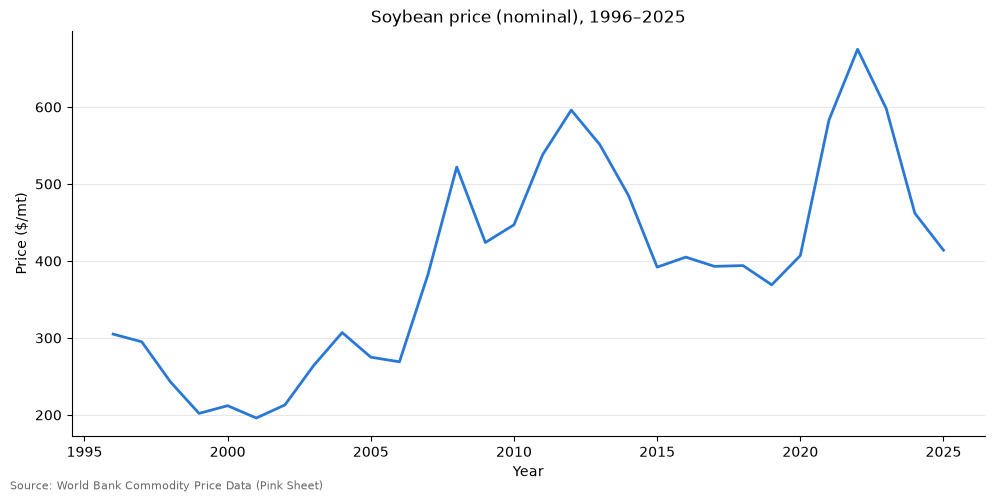

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybeans"], color="#2a78d6", linewidth=2)
ax.set_title("Soybean price (nominal), 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/mt)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

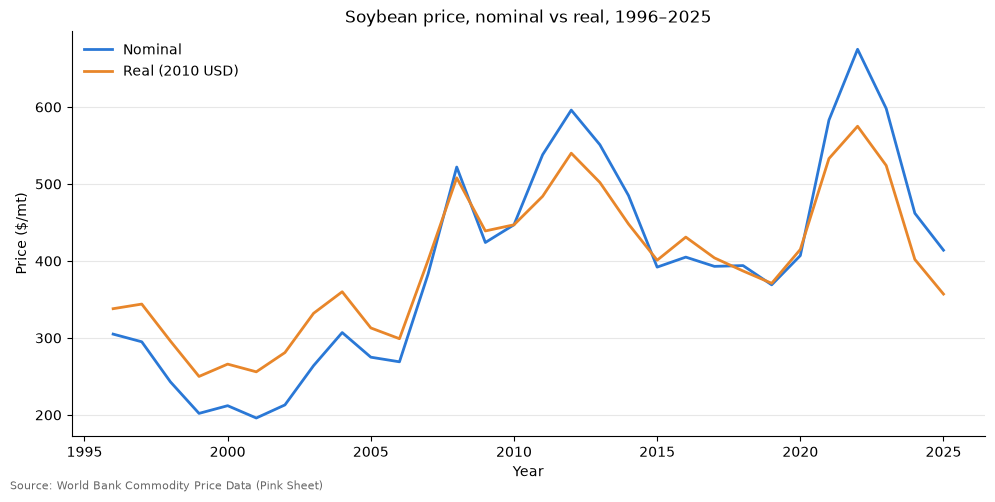

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybeans"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Soybeans"], color="#e8862a", linewidth=2, label="Real (2010 USD)")
ax.set_title("Soybean price, nominal vs real, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/mt)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

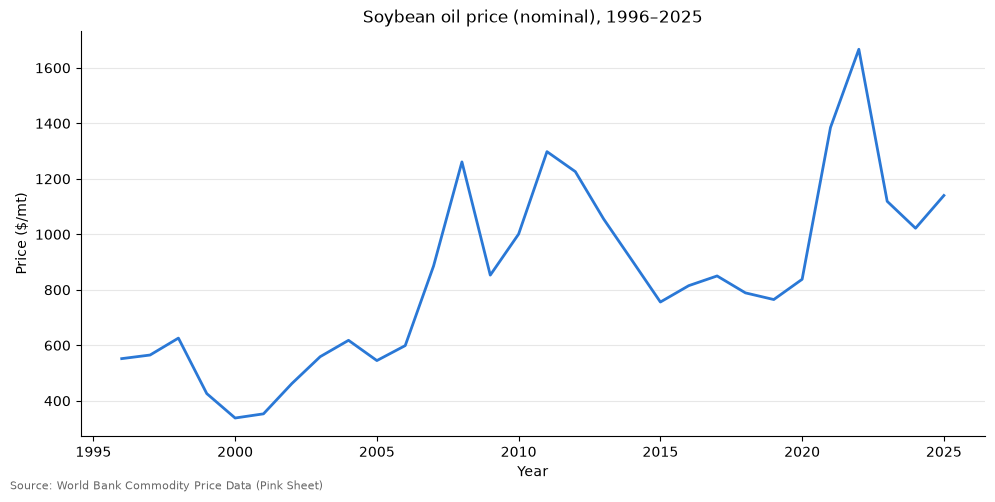

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybean oil"], color="#2a78d6", linewidth=2)
ax.set_title("Soybean oil price (nominal), 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/mt)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

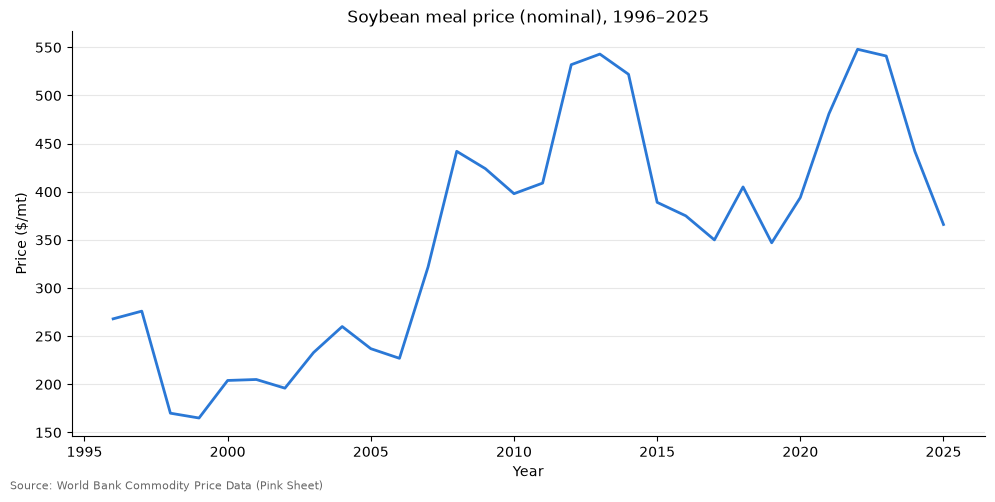

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybean meal"], color="#2a78d6", linewidth=2)
ax.set_title("Soybean meal price (nominal), 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/mt)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

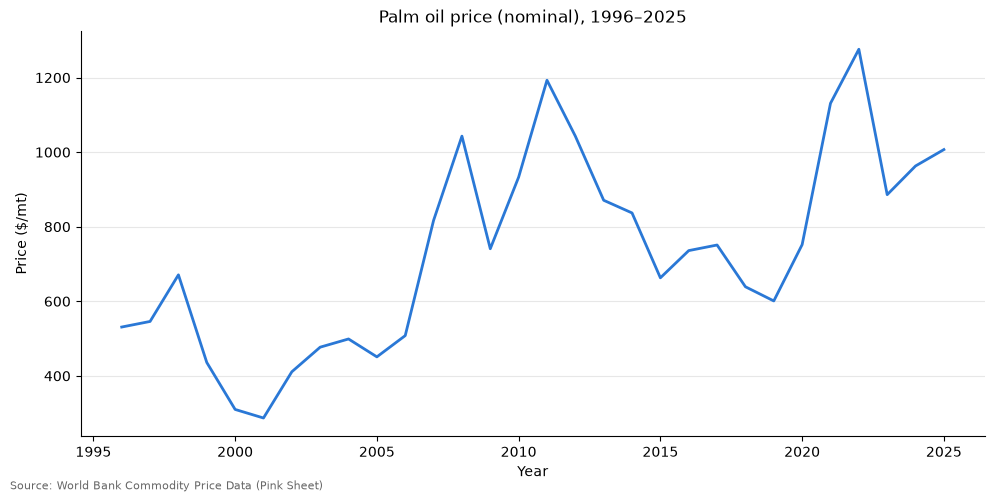

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm oil"], color="#2a78d6", linewidth=2)
ax.set_title("Palm oil price (nominal), 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/mt)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

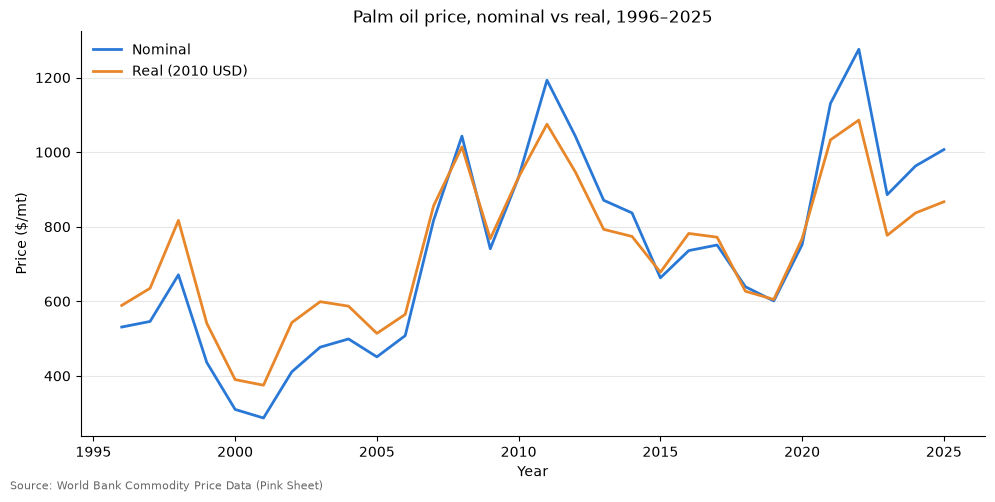

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm oil"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Palm oil"], color="#e8862a", linewidth=2, label="Real (2010 USD)")
ax.set_title("Palm oil price, nominal vs real, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/mt)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

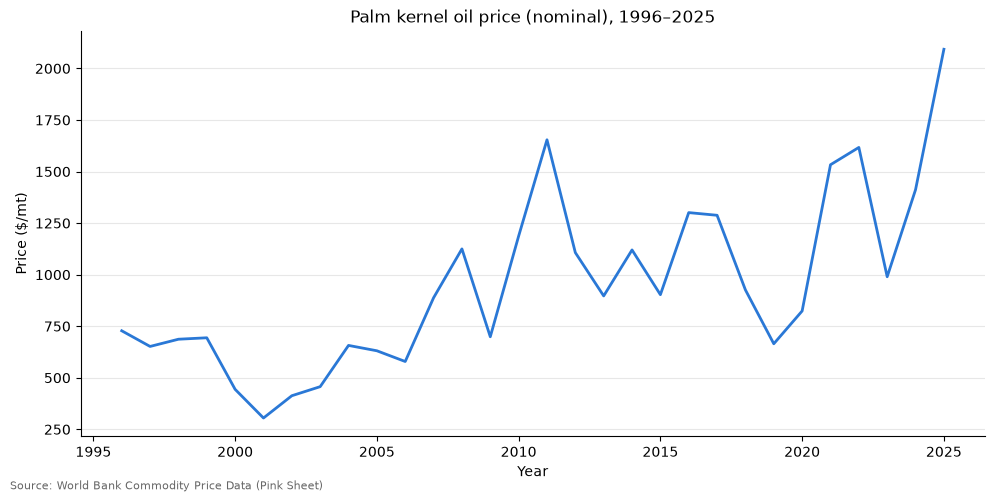

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm kernel oil"], color="#2a78d6", linewidth=2)
ax.set_title("Palm kernel oil price (nominal), 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/mt)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

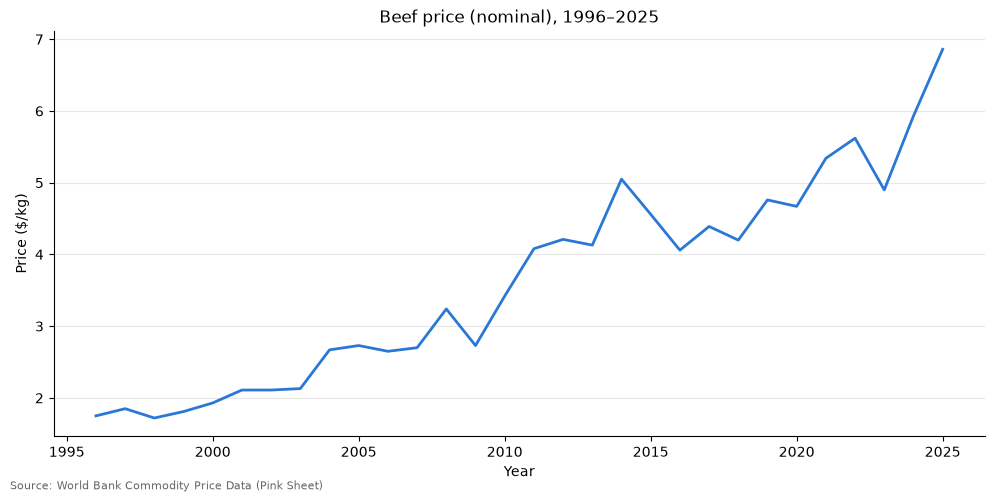

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Beef"], color="#2a78d6", linewidth=2)
ax.set_title("Beef price (nominal), 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/kg)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

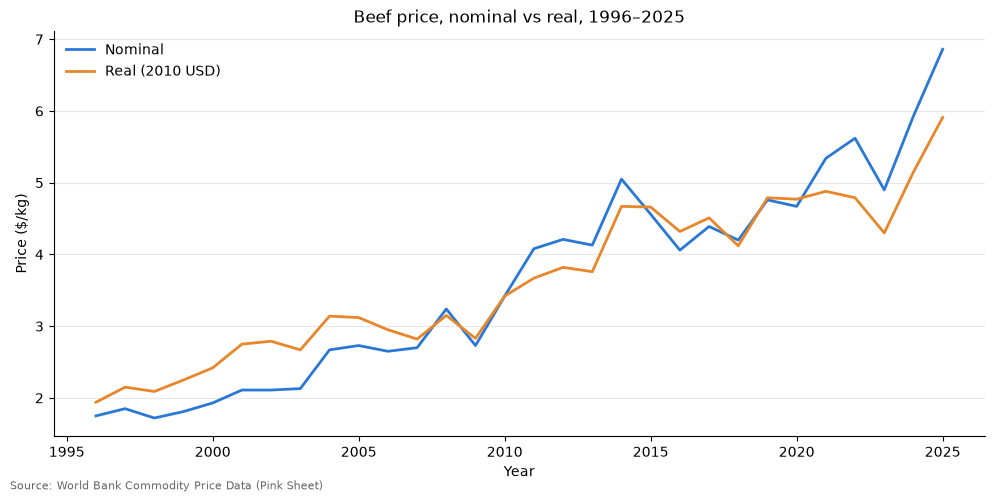

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Beef"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Beef"], color="#e8862a", linewidth=2, label="Real (2010 USD)")
ax.set_title("Beef price, nominal vs real, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/kg)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

From here we start analysing price per country

In [15]:
price_data = pd.read_csv(BASE_URL + "raw/crops/FAOSTAT_2.0.csv")
price_data.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Months Code,Months,Unit,Value,Flag,Flag Description
0,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1993,1993,7021,Annual value,USD,3116.2,A,Official value
1,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1994,1994,7021,Annual value,USD,2071.4,A,Official value
2,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1995,1995,7021,Annual value,USD,2481.2,A,Official value
3,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1996,1996,7021,Annual value,USD,2870.8,A,Official value
4,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1997,1997,7021,Annual value,USD,2350.1,A,Official value


In [16]:
cattle = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Meat of cattle with the bone, fresh or chilled"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)
cattle.head()



,Area,Item,Year,Unit,Value
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2


In [17]:
beef = df.loc[df["year"] >= 1996, ["year", "Beef"]]

cattle = cattle.merge(beef, left_on="Year", right_on="year", how="left").drop(columns="year")

# world price in $/tonne, like the FAOSTAT producer price
cattle["Beef"] = cattle["Beef"] * 1000
cattle = cattle.rename(columns={"Beef": "World price"})
cattle.head()

,Area,Item,Year,Unit,Value,World price
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8,1750.0
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1,1850.0
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2,1720.0
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0,1810.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2,1930.0


In [18]:
palm_oil = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Palm oil"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)

palm = df.loc[df["year"] >= 1996, ["year", "Palm oil"]]
palm_oil = palm_oil.merge(palm, left_on="Year", right_on="year", how="left").drop(columns="year")
palm_oil = palm_oil.rename(columns={"Palm oil": "World price"})
palm_oil.head()

,Area,Item,Year,Unit,Value,World price
0,Burundi,Palm oil,1996,USD,881.9,531
1,Burundi,Palm oil,1997,USD,1419.0,546
2,Burundi,Palm oil,1998,USD,1398.1,671
3,Burundi,Palm oil,1999,USD,824.3,436
4,Burundi,Palm oil,2000,USD,1317.7,310


In [19]:
soy = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Soya beans"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)

soybeans = df.loc[df["year"] >= 1996, ["year", "Soybeans"]]
soy = soy.merge(soybeans, left_on="Year", right_on="year", how="left").drop(columns="year")
soy = soy.rename(columns={"Soybeans": "World price"})
soy.head()

,Area,Item,Year,Unit,Value,World price
0,Albania,Soya beans,1996,USD,478.5,305
1,Albania,Soya beans,1997,USD,335.7,295
2,Albania,Soya beans,1998,USD,331.9,243
3,Albania,Soya beans,1999,USD,435.8,202
4,Albania,Soya beans,2000,USD,487.1,212


In [20]:
for d in [cattle, soy, palm_oil]:
    if "ISO3" not in d.columns:
        pos = d.columns.get_loc("Area") + 1
        d.insert(pos, "ISO3", coco.convert(names=d["Area"], to="ISO3"))


pays_liste = ['Angola', 'Argentina', 'Australia', 'Bangladesh', 'Belize', 'Bolivia', 'Brazil', 'Bhutan',
              'Central African Republic', "Côte d'Ivoire", 'Cameroon', 'Democratic Republic of the Congo',
              'Republic of the Congo', 'Colombia', 'Costa Rica', 'Cuba', 'Dominican Republic', 'Ecuador',
              'Ethiopia', 'Fiji', 'Gabon', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Equatorial Guinea',
              'Guatemala', 'Guyana', 'Honduras', 'Indonesia', 'India', 'Kenya', 'Cambodia', 'Laos',
              'Liberia', 'Sri Lanka', 'Madagascar', 'Mexico', 'Myanmar', 'Mozambique', 'Malawi',
              'Malaysia', 'Nigeria', 'Nicaragua', 'Nepal', 'Panama', 'Peru', 'Philippines',
              'Papua New Guinea', 'Paraguay', 'Solomon Islands', 'Sierra Leone', 'South Sudan',
              'Suriname', 'Thailand', 'Taiwan', 'Tanzania', 'Uganda', 'Venezuela', 'Vietnam',
              'Vanuatu', 'South Africa', 'Zambia', 'Zimbabwe']

iso3_liste = coco.convert(names=pays_liste, to="ISO3")

cattle = cattle[cattle["ISO3"].isin(iso3_liste)].reset_index(drop=True)
soy = soy[soy["ISO3"].isin(iso3_liste)].reset_index(drop=True)
palm_oil = palm_oil[palm_oil["ISO3"].isin(iso3_liste)].reset_index(drop=True)

cattle.head()
soy.head()
palm_oil.head()

Serbia and Montenegro not found in regex


Serbia and Montenegro not found in regex


Serbia and Montenegro not found in regex


Serbia and Montenegro not found in regex


Serbia and Montenegro not found in regex


...

Serbia and Montenegro not found in regex


Serbia and Montenegro not found in regex


Serbia and Montenegro not found in regex


Serbia and Montenegro not found in regex


,Area,ISO3,Item,Year,Unit,Value,World price
0,Cameroon,CMR,Palm oil,1996,USD,567.8,531
1,Cameroon,CMR,Palm oil,1997,USD,562.5,546
2,Cameroon,CMR,Palm oil,1998,USD,571.9,671
3,Cameroon,CMR,Palm oil,1999,USD,561.2,436
4,Cameroon,CMR,Palm oil,2000,USD,476.4,310


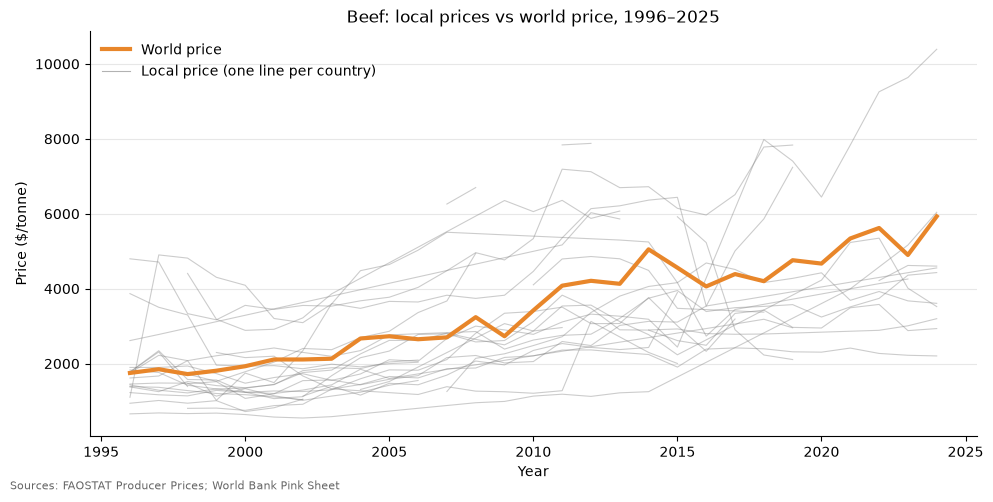

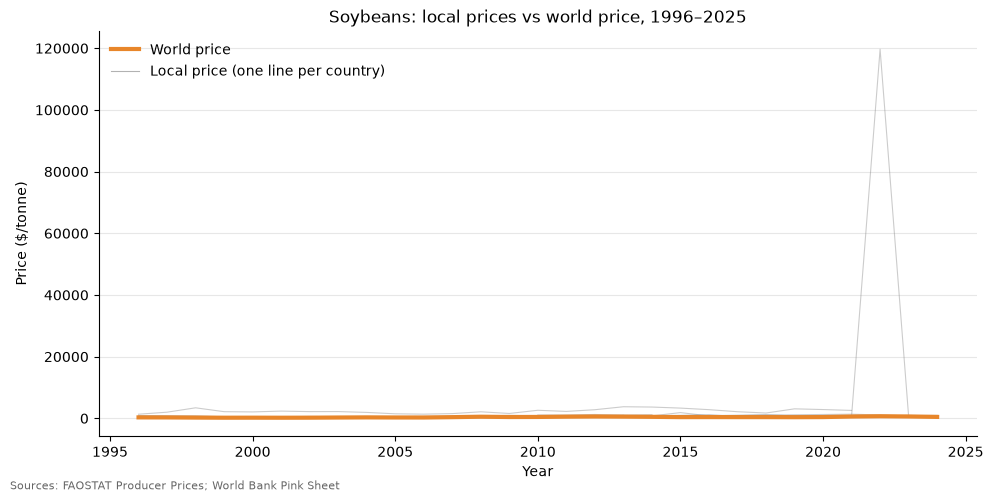

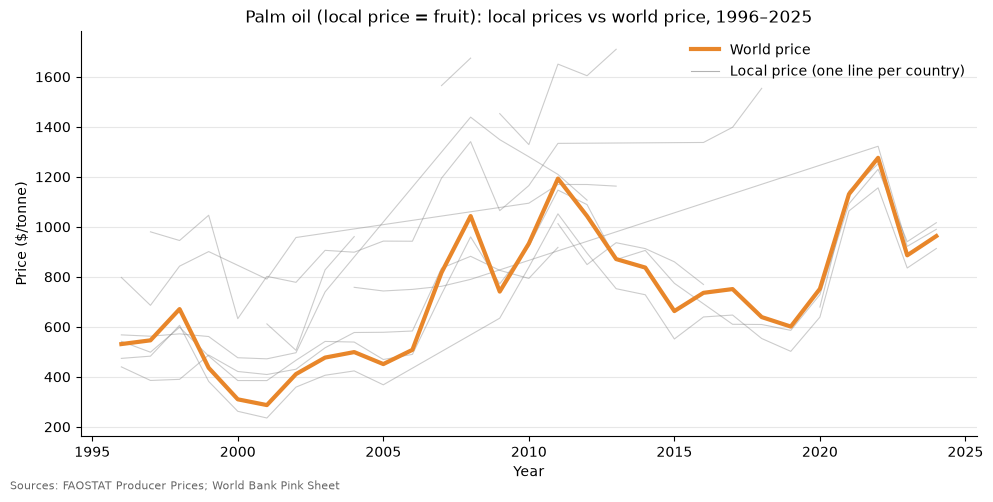

In [21]:
datasets = [
    (cattle, "Beef"),
    (soy, "Soybeans"),
    (palm_oil, "Palm oil (local price = fruit)"),
]

for data, titre in datasets:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Une ligne grise par pays
    for pays, d in data.groupby("Area"):
        d = d.sort_values("Year")
        ax.plot(d["Year"], d["Value"], color="grey", linewidth=0.8, alpha=0.4)

    # Prix mondial en couleur, par-dessus
    monde = data.drop_duplicates("Year").sort_values("Year")
    ax.plot(monde["Year"], monde["World price"], color="#e8862a", linewidth=3, label="World price")

    ax.plot([], [], color="grey", linewidth=0.8, alpha=0.6, label="Local price (one line per country)")
    ax.set_title(f"{titre}: local prices vs world price, 1996–2025")
    ax.set_xlabel("Year")
    ax.set_ylabel("Price ($/tonne)")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    add_source(fig, SOURCE_FAO)
    plt.tight_layout()
    plt.show()

In [22]:
for nom, d in [("cattle", cattle), ("soy", soy), ("palm_oil", palm_oil)]:
    print(nom, ":", d["Area"].nunique(), "pays")
    print(sorted(d["Area"].unique()), "\n")





cattle : 31 pays
['Argentina', 'Australia', 'Bangladesh', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil', 'Cambodia', 'Colombia', 'Congo', 'Dominican Republic', 'Fiji', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Honduras', 'Indonesia', 'Kenya', "Lao People's Democratic Republic", 'Madagascar', 'Malawi', 'Malaysia', 'Mexico', 'Mozambique', 'Nicaragua', 'Nigeria', 'Peru', 'South Africa', 'Sri Lanka', 'Suriname', 'Viet Nam', 'Zambia'] 

soy : 34 pays
['Angola', 'Argentina', 'Australia', 'Bangladesh', 'Belize', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil', 'Cambodia', 'Colombia', "Côte d'Ivoire", 'Ecuador', 'Ethiopia', 'India', 'Indonesia', 'Kenya', "Lao People's Democratic Republic", 'Malawi', 'Mexico', 'Nepal', 'Nicaragua', 'Nigeria', 'Paraguay', 'Peru', 'Philippines', 'South Africa', 'Sri Lanka', 'Suriname', 'Thailand', 'United Republic of Tanzania', 'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Zambia', 'Zimbabwe'] 

palm_oil : 12 pays
['Cameroon', 'Colombia', 'Congo',

In [23]:
def garder_pays_10_ans(d, min_annees=10):
    n_annees = d.dropna(subset=["Value"]).groupby("Area")["Year"].nunique()
    pays_ok = n_annees[n_annees >= min_annees].index
    return d[d["Area"].isin(pays_ok)].reset_index(drop=True)

cattle = garder_pays_10_ans(cattle)
soy = garder_pays_10_ans(soy)
palm_oil = garder_pays_10_ans(palm_oil)

for nom, d in [("cattle", cattle), ("soy", soy), ("palm_oil", palm_oil)]:
    print(nom, ":", d["Area"].nunique(), "pays")


cattle : 20 pays
soy : 27 pays
palm_oil : 6 pays


In [24]:
sorted(cattle["Area"].unique())



['Australia',
 'Bhutan',
 'Brazil',
 'Colombia',
 'Congo',
 'Dominican Republic',
 'Fiji',
 'Guinea',
 'Kenya',
 'Malawi',
 'Malaysia',
 'Mexico',
 'Mozambique',
 'Nicaragua',
 'Nigeria',
 'Peru',
 'South Africa',
 'Sri Lanka',
 'Suriname',
 'Viet Nam']

In [25]:
sorted(soy["Area"].unique())

['Argentina',
 'Australia',
 'Bangladesh',
 'Bhutan',
 'Bolivia (Plurinational State of)',
 'Brazil',
 'Cambodia',
 'Colombia',
 'Ecuador',
 'Ethiopia',
 'India',
 'Indonesia',
 "Lao People's Democratic Republic",
 'Malawi',
 'Mexico',
 'Nepal',
 'Nicaragua',
 'Nigeria',
 'Paraguay',
 'Peru',
 'Philippines',
 'South Africa',
 'Sri Lanka',
 'Suriname',
 'Thailand',
 'Viet Nam',
 'Zimbabwe']

In [26]:
sorted(palm_oil["Area"].unique())

['Cameroon', 'Colombia', "Côte d'Ivoire", 'Ghana', 'Malaysia', 'Nigeria']

In [27]:
palm_oil.head()

,Area,ISO3,Item,Year,Unit,Value,World price
0,Cameroon,CMR,Palm oil,1996,USD,567.8,531
1,Cameroon,CMR,Palm oil,1997,USD,562.5,546
2,Cameroon,CMR,Palm oil,1998,USD,571.9,671
3,Cameroon,CMR,Palm oil,1999,USD,561.2,436
4,Cameroon,CMR,Palm oil,2000,USD,476.4,310


FAOSTAT has producer prices of palm oil for Indonesia only for 1991–1992, so we add 2001–2023 by hand.

**Source of the Indonesian prices:** TODO (David): name the source (publication, table, link) and the date it was downloaded.

The cell first removes any Indonesia row already in the table, so running it twice does not add the years twice.

In [28]:
indonesia_prix = {
    2001: 238.4,
    2002: 356.7,
    2003: 410.4,
    2004: 434.7,
    2005: 367.7,
    2006: 416.8,
    2007: 719.1,
    2008: 863.1,
    2009: 644.0,
    2010: 859.9,
    2011: 1076.5,
    2012: 939.8,
    2013: 764.2,
    2014: 739.4,
    2015: 565.1,
    2016: 639.8,
    2017: 647.8,
    2018: 559.9,
    2019: 524.0,
    2020: 666.1,
    2021: 769.7,
    2022: 823.9,
    2023: 737.7,
}

indonesia = pd.DataFrame({
    "Area": "Indonesia",
    "ISO3": "IDN",
    "Item": "Palm oil",
    "Year": list(indonesia_prix.keys()),
    "Unit": "USD",
    "Value": list(indonesia_prix.values()),
})

# Ajouter le prix mondial de la même année
indonesia = indonesia.merge(df[["year", "Palm oil"]], left_on="Year", right_on="year", how="left")
indonesia = indonesia.drop(columns="year").rename(columns={"Palm oil": "World price"})

palm_oil = palm_oil[palm_oil["Area"] != "Indonesia"]
palm_oil = pd.concat([palm_oil, indonesia[palm_oil.columns]], ignore_index=True)
assert not palm_oil.duplicated(["Area", "Year"]).any()
palm_oil[palm_oil["Area"] == "Indonesia"]

,Area,ISO3,Item,Year,Unit,Value,World price
111,Indonesia,IDN,Palm oil,2001,USD,238.4,287
112,Indonesia,IDN,Palm oil,2002,USD,356.7,411
113,Indonesia,IDN,Palm oil,2003,USD,410.4,477
114,Indonesia,IDN,Palm oil,2004,USD,434.7,499
115,Indonesia,IDN,Palm oil,2005,USD,367.7,451
116,Indonesia,IDN,Palm oil,2006,USD,416.8,508
117,Indonesia,IDN,Palm oil,2007,USD,719.1,817
118,Indonesia,IDN,Palm oil,2008,USD,863.1,1043
119,Indonesia,IDN,Palm oil,2009,USD,644.0,741
120,Indonesia,IDN,Palm oil,2010,USD,859.9,933


In [29]:
palm_oil.head()

,Area,ISO3,Item,Year,Unit,Value,World price
0,Cameroon,CMR,Palm oil,1996,USD,567.8,531
1,Cameroon,CMR,Palm oil,1997,USD,562.5,546
2,Cameroon,CMR,Palm oil,1998,USD,571.9,671
3,Cameroon,CMR,Palm oil,1999,USD,561.2,436
4,Cameroon,CMR,Palm oil,2000,USD,476.4,310


In [30]:
sorted(palm_oil["Area"].unique())

['Cameroon',
 'Colombia',
 "Côte d'Ivoire",
 'Ghana',
 'Indonesia',
 'Malaysia',
 'Nigeria']

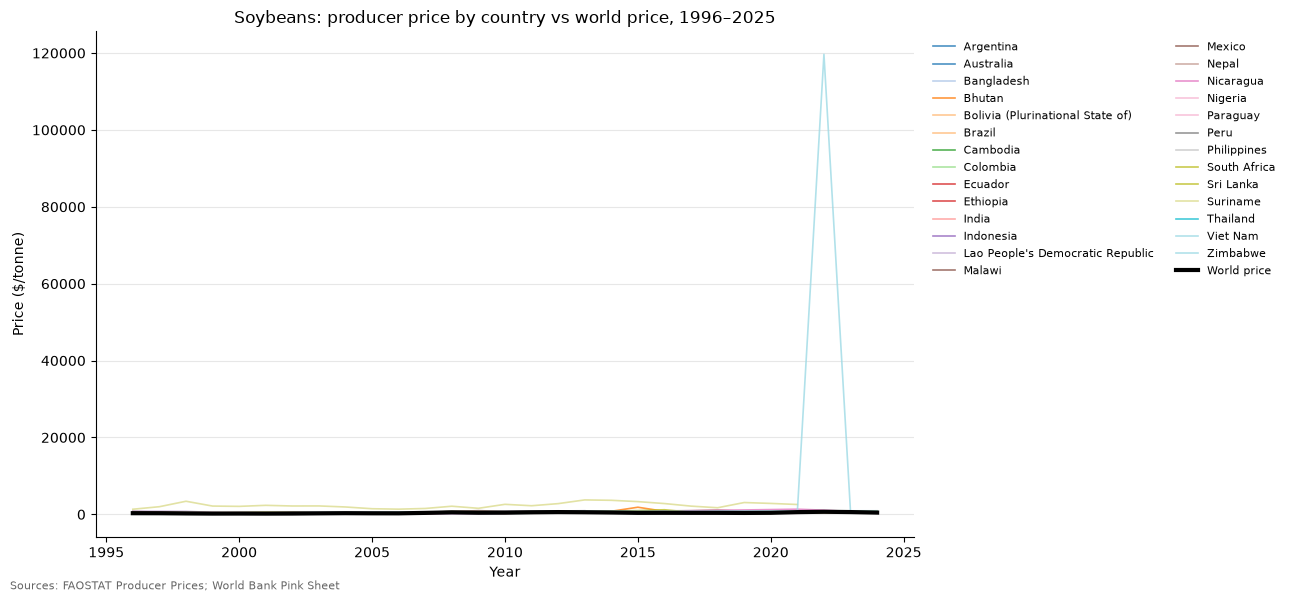

In [31]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(soy["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = soy[soy["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = soy.drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, label="World price")

ax.set_title("Soybeans: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()

In [32]:
masque = (soy["Area"] == "Zimbabwe") & (soy["Year"] == 2022)
soy.loc[masque, "Value"] = np.nan

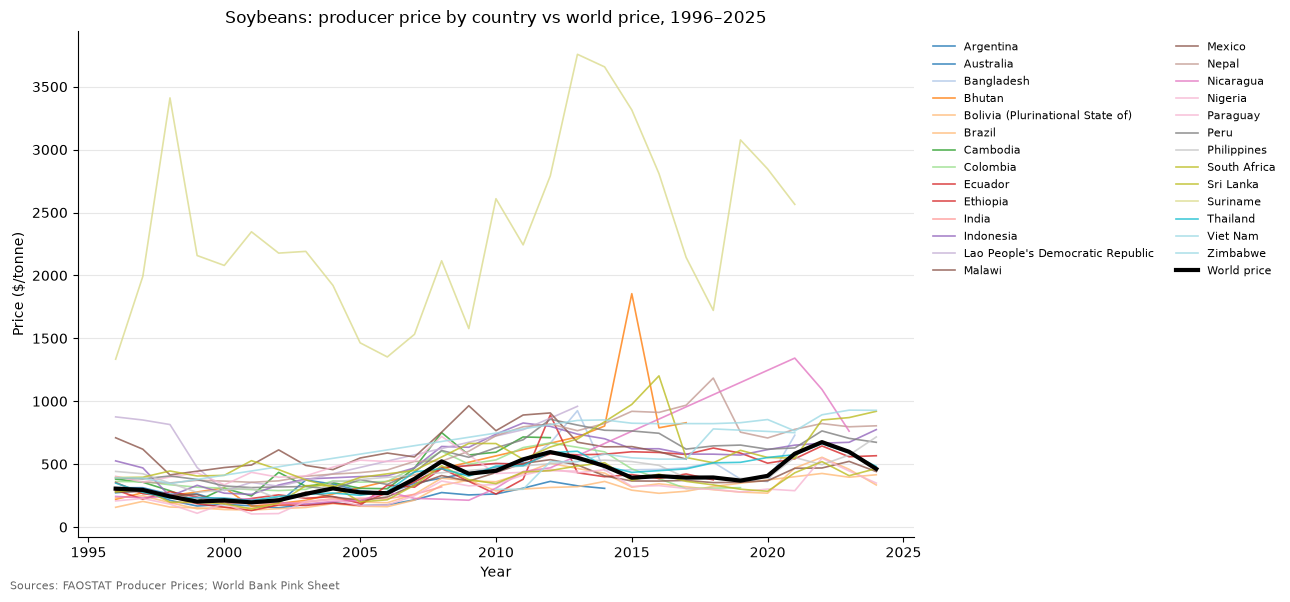

In [33]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(soy["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = soy[soy["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = soy.drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, label="World price")

ax.set_title("Soybeans: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()

In [34]:
soy = soy[soy["Area"] != "Suriname"].reset_index(drop=True)


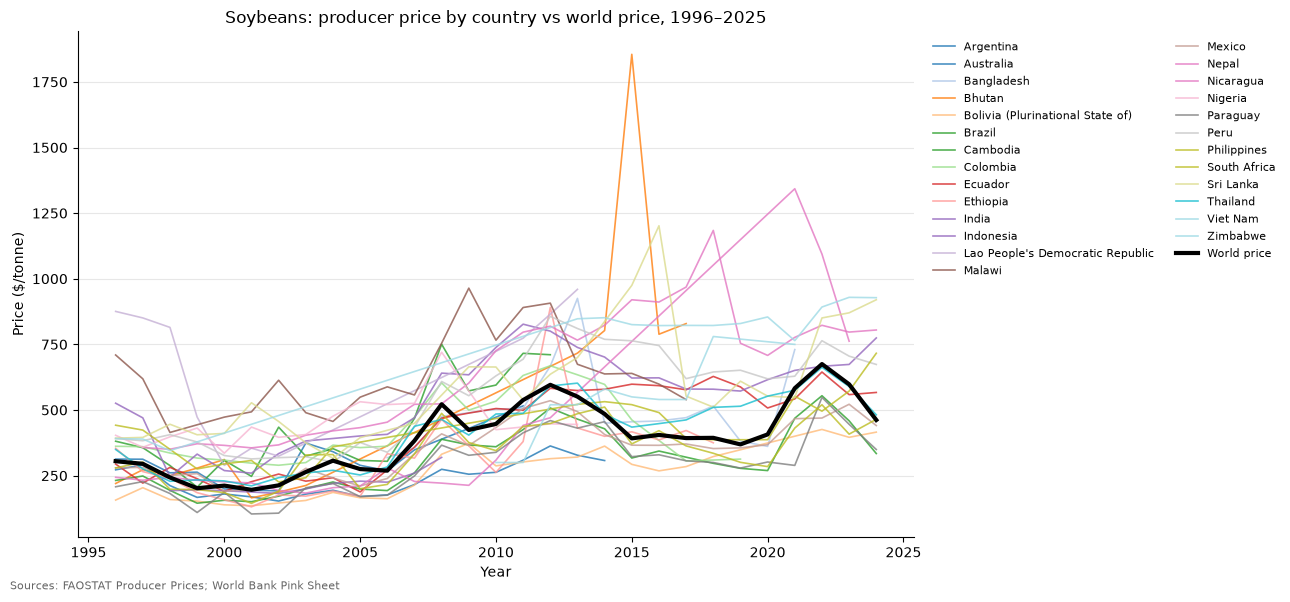

In [35]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(soy["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = soy[soy["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = soy.drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, label="World price")

ax.set_title("Soybeans: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()

FAOSTAT has producer prices of cattle meat for Argentina only for 2015–2019, so we add 2001–2019 by hand.

**Source of the Argentinian prices:** TODO (David): name the source and the date it was downloaded.

As for Indonesia, the cell first removes the Argentina rows already in the table, so running it twice does not add the years twice.

In [36]:
argentina_prix = {
    2001: 770,
    2002: 480,
    2003: 640,
    2004: 680,
    2005: 770,
    2006: 760,
    2007: 850,
    2008: 930,
    2009: 860,
    2010: 1660,
    2011: 1980,
    2012: 1960,
    2013: 1770,
    2014: 1860,
    2015: 1920,
    2016: 1760,
    2017: 1760,
    2018: 1360,
    2019: 1365,
}

argentina = pd.DataFrame({
    "Area": "Argentina",
    "ISO3": "ARG",
    "Item": "Meat of cattle with the bone, fresh or chilled",
    "Year": list(argentina_prix.keys()),
    "Unit": "USD",
    "Value": list(argentina_prix.values()),
})

# Ajouter le prix mondial du bœuf (en $/tonne)
beef = df[["year", "Beef"]].assign(Beef=df["Beef"] * 1000)
argentina = argentina.merge(beef, left_on="Year", right_on="year", how="left")
argentina = argentina.drop(columns="year").rename(columns={"Beef": "World price"})

cattle = cattle[cattle["Area"] != "Argentina"]
cattle = pd.concat([cattle, argentina[cattle.columns]], ignore_index=True)
assert not cattle.duplicated(["Area", "Year"]).any()
cattle[cattle["Area"] == "Argentina"]

,Area,ISO3,Item,Year,Unit,Value,World price
379,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2001,USD,770.0,2110.0
380,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2002,USD,480.0,2110.0
381,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2003,USD,640.0,2130.0
382,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2004,USD,680.0,2670.0
383,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2005,USD,770.0,2730.0
384,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2006,USD,760.0,2650.0
385,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2007,USD,850.0,2700.0
386,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2008,USD,930.0,3240.0
387,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2009,USD,860.0,2730.0
388,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2010,USD,1660.0,3420.0


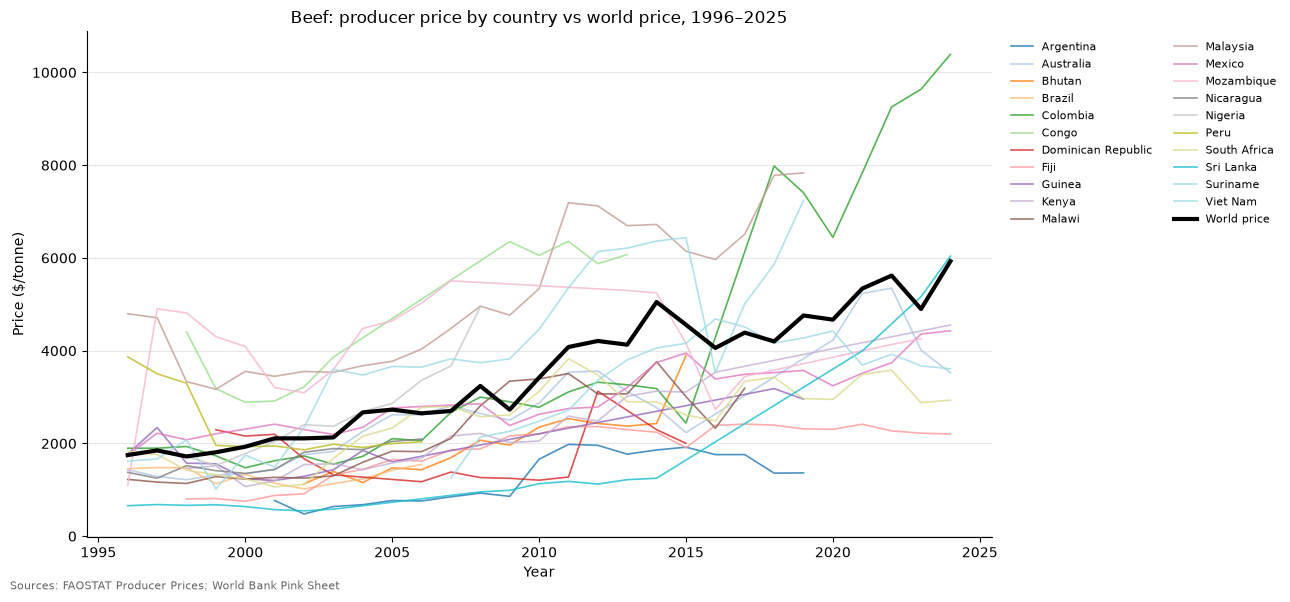

In [37]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(cattle["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = cattle[cattle["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = cattle.dropna(subset=["World price"]).drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, label="World price")

ax.set_title("Beef: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()


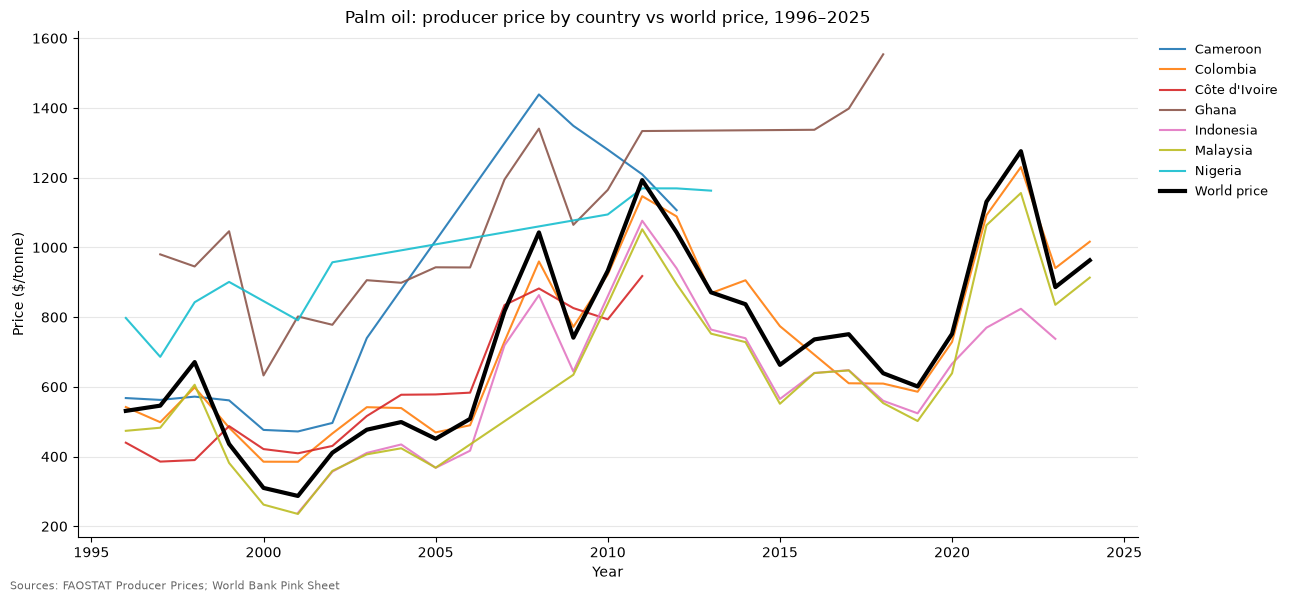

In [38]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(palm_oil["Area"].unique())
couleurs = plt.cm.tab10(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = palm_oil[palm_oil["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.5, alpha=0.9, label=p)

monde = palm_oil.dropna(subset=["World price"]).drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, label="World price")

ax.set_title("Palm oil: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()


In [39]:
for nom, d in [("cattle", cattle), ("soy", soy), ("palm_oil", palm_oil)]:
    pays = sorted(d["Area"].unique())
    print(f"{nom} : {len(pays)} pays")
    print(pays, "\n")



cattle : 21 pays
['Argentina', 'Australia', 'Bhutan', 'Brazil', 'Colombia', 'Congo', 'Dominican Republic', 'Fiji', 'Guinea', 'Kenya', 'Malawi', 'Malaysia', 'Mexico', 'Mozambique', 'Nicaragua', 'Nigeria', 'Peru', 'South Africa', 'Sri Lanka', 'Suriname', 'Viet Nam'] 

soy : 26 pays
['Argentina', 'Australia', 'Bangladesh', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil', 'Cambodia', 'Colombia', 'Ecuador', 'Ethiopia', 'India', 'Indonesia', "Lao People's Democratic Republic", 'Malawi', 'Mexico', 'Nepal', 'Nicaragua', 'Nigeria', 'Paraguay', 'Peru', 'Philippines', 'South Africa', 'Sri Lanka', 'Thailand', 'Viet Nam', 'Zimbabwe'] 

palm_oil : 7 pays
['Cameroon', 'Colombia', "Côte d'Ivoire", 'Ghana', 'Indonesia', 'Malaysia', 'Nigeria'] 



## Does the local price follow the world price?

The difference between the local and the world price mostly reflects transport costs, quality and the exchange rate, so it does not tell us whether world price shocks reach the farmers. Instead, for each country and commodity we correlate the **year-to-year changes** of the two prices (change in log price, i.e. approximately the % change).

- Only consecutive years are compared: if a year is missing, the change before and after it is dropped.
- A country needs at least 8 annual changes for its correlation to be shown.
- We say that the local price **follows** the world price when the correlation is above 0.5.

The sample is all countries kept above (at least 10 years of producer prices, plus Indonesia and Argentina added by hand), not only the main producers.

In [40]:
MIN_CHANGES = 8
SEUIL = 0.5


def correlation_par_pays(d, commodity):
    lignes = []
    for pays, g in d.dropna(subset=["Value", "World price"]).groupby("Area"):
        g = g.set_index("Year").sort_index()
        g = g.reindex(range(g.index.min(), g.index.max() + 1))  # missing years become NaN, so their change is NaN
        d_local = np.log(g["Value"]).diff()
        d_monde = np.log(g["World price"]).diff()
        ok = d_local.notna() & d_monde.notna()
        if ok.sum() >= MIN_CHANGES:
            lignes.append({"commodity": commodity, "country": pays, "n_changes": int(ok.sum()),
                           "corr": d_local[ok].corr(d_monde[ok])})
    return pd.DataFrame(lignes)


corr = pd.concat([
    correlation_par_pays(cattle, "Beef"),
    correlation_par_pays(soy, "Soybeans"),
    correlation_par_pays(palm_oil, "Palm oil"),
], ignore_index=True)
corr["follows"] = corr["corr"] > SEUIL
corr.sort_values(["commodity", "corr"], ascending=[True, False]).round(2)

,commodity,country,n_changes,corr,follows
0,Beef,Argentina,18,0.50,False
10,Beef,Malawi,21,0.48,False
8,Beef,Guinea,11,0.47,False
15,Beef,Nigeria,10,0.47,False
1,Beef,Australia,23,0.46,False
11,Beef,Malaysia,23,0.46,False
12,Beef,Mexico,28,0.40,False
17,Beef,South Africa,28,0.35,False
18,Beef,Sri Lanka,14,0.34,False
4,Beef,Colombia,25,0.29,False


In [41]:
resume = corr.groupby("commodity").agg(countries=("country", "size"), follow=("follows", "sum"))
print(resume, "\n")

n_suit = corr.loc[corr["follows"], "country"].nunique()
n_pays = corr["country"].nunique()
print(f"The local price follows the world price (correlation of annual changes > {SEUIL}) "
      f"in {corr['follows'].sum()} of {len(corr)} country-commodity series, "
      f"i.e. in {n_suit} of {n_pays} countries for at least one commodity.")

           countries  follow
commodity                   
Beef              21       0
Palm oil           6       3
Soybeans          26      12 

The local price follows the world price (correlation of annual changes > 0.5) in 15 of 53 country-commodity series, i.e. in 14 of 37 countries for at least one commodity.


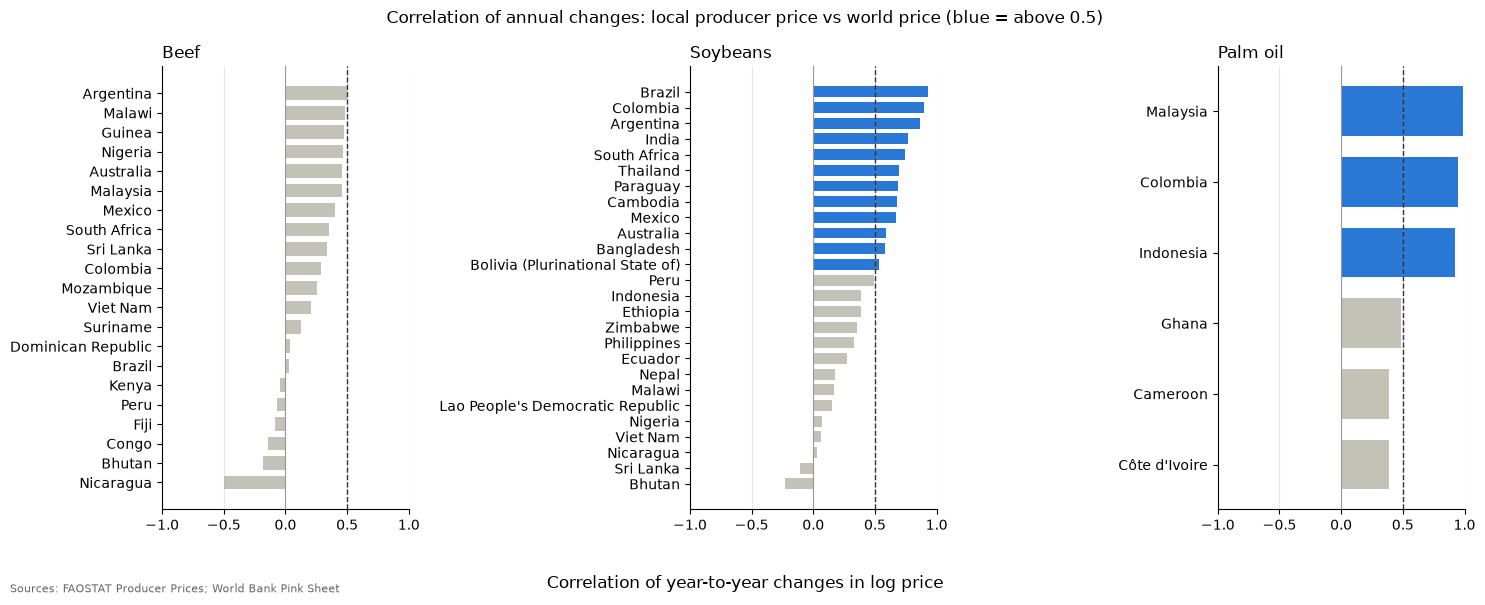

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True)

for ax, c in zip(axes, ["Beef", "Soybeans", "Palm oil"]):
    d = corr[corr["commodity"] == c].sort_values("corr")
    ax.barh(d["country"], d["corr"], color=np.where(d["follows"], "#2a78d6", "#c3c2b7"), height=0.7)
    ax.axvline(SEUIL, color="#333333", linewidth=1, linestyle="--")
    ax.axvline(0, color="#999999", linewidth=0.8)
    ax.set_title(c, loc="left")
    ax.set_xlim(-1, 1)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Correlation of annual changes: local producer price vs world price (blue = above 0.5)")
fig.supxlabel("Correlation of year-to-year changes in log price")
add_source(fig, SOURCE_FAO)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

From here we have the definitive list of the main producers. These lists describe production; they do not choose the sample of the analysis.

In [43]:
palm_principaux = ['Indonesia', 'Malaysia', 'Thailand', 'Nigeria', 'Colombia']
palm_principaux = ['Indonesia', 'Malaysia', 'Thailand', 'Nigeria', 'Colombia']

palm_oil = palm_oil[palm_oil["Area"].isin(palm_principaux)].reset_index(drop=True)
sorted(palm_oil["Area"].unique())
palm_oil.head()


,Area,ISO3,Item,Year,Unit,Value,World price
0,Colombia,COL,Palm oil,1996,USD,542.0,531
1,Colombia,COL,Palm oil,1997,USD,498.5,546
2,Colombia,COL,Palm oil,1998,USD,598.4,671
3,Colombia,COL,Palm oil,1999,USD,483.0,436
4,Colombia,COL,Palm oil,2000,USD,385.2,310


In [44]:
soy_principaux = ['Brazil', 'Argentina', 'India',  'Paraguay']
soy_principaux = ['Brazil', 'Argentina', 'India', 'Paraguay']

soy = soy[soy["Area"].isin(soy_principaux)].reset_index(drop=True)
sorted(soy["Area"].unique())
soy.head()


,Area,ISO3,Item,Year,Unit,Value,World price
0,Argentina,ARG,Soya beans,1996,USD,272.1,305
1,Argentina,ARG,Soya beans,1997,USD,291.1,295
2,Argentina,ARG,Soya beans,1998,USD,212.1,243
3,Argentina,ARG,Soya beans,1999,USD,167.1,202
4,Argentina,ARG,Soya beans,2000,USD,180.1,212


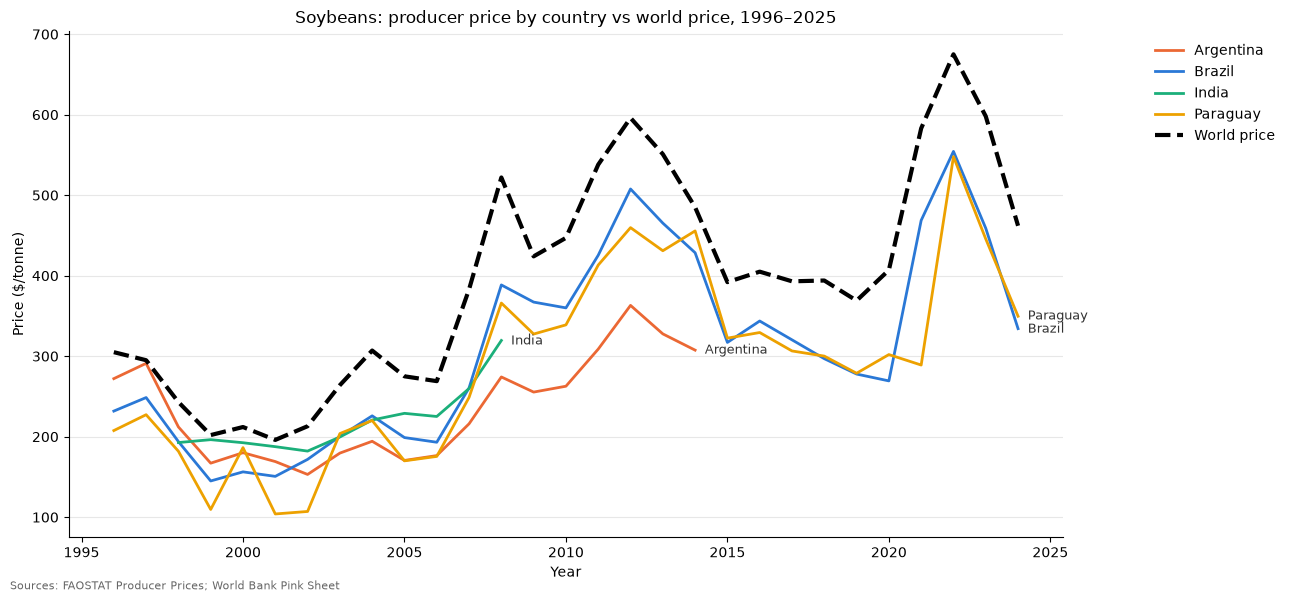

In [45]:
couleurs = {
    "Brazil": "#2a78d6",
    "Argentina": "#eb6834",
    "India": "#1baf7a",
    "Paraguay": "#eda100",
}

fig, ax = plt.subplots(figsize=(13, 6))

for p in sorted(soy["Area"].unique()):
    d = soy[soy["Area"] == p].sort_values("Year")
    c = couleurs.get(p, "#999999")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=2, label=p)
    ax.text(d["Year"].iloc[-1] + 0.3, d["Value"].iloc[-1], p, color="#333333", fontsize=9, va="center")

monde = soy.dropna(subset=["World price"]).drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, linestyle="--", label="World price")

ax.set_title("Soybeans: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, bbox_to_anchor=(1.08, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()


In [46]:
mexico = price_data.loc[
    (price_data["Area"] == "Mexico")
    & (price_data["Item"] == "Meat of cattle with the bone, fresh or chilled")
    & (price_data["Year"] >= 1996),
    ["Area", "Item", "Year", "Unit", "Value"]
].copy()
mexico.insert(1, "ISO3", "MEX")

# Prix mondial du bœuf en $/tonne
beef = df[["year", "Beef"]].assign(Beef=df["Beef"] * 1000)
mexico = mexico.merge(beef, left_on="Year", right_on="year", how="left")
mexico = mexico.drop(columns="year").rename(columns={"Beef": "World price"})

cattle = cattle[cattle["Area"] != "Mexico"]
cattle = pd.concat([cattle, mexico[cattle.columns]], ignore_index=True)
cattle[cattle["Area"] == "Mexico"]

,Area,ISO3,Item,Year,Unit,Value,World price
369,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",1996,USD,1748.8,1750.0
370,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",1997,USD,2221.4,1850.0
371,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",1998,USD,2078.6,1720.0
372,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",1999,USD,2209.1,1810.0
373,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",2000,USD,2308.7,1930.0
374,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",2001,USD,2417.0,2110.0
375,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",2002,USD,2299.1,2110.0
376,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",2003,USD,2193.9,2130.0
377,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",2004,USD,2347.2,2670.0
378,Mexico,MEX,"Meat of cattle with the bone, fresh or chilled",2005,USD,2765.7,2730.0


In [47]:
cattle_principaux = ['Brazil', 'India', 'Argentina', 'Australia', 'Mexico', 'South Africa', 'Colombia']
cattle_principaux = ['Brazil', 'India', 'Argentina', 'Australia', 'Mexico', 'South Africa', 'Colombia']

cattle = cattle[cattle["Area"].isin(cattle_principaux)].reset_index(drop=True)
sorted(cattle["Area"].unique())


['Argentina', 'Australia', 'Brazil', 'Colombia', 'Mexico', 'South Africa']

l'inde n'est pas pris en compte car on a pas assez de données et en plus surtout du buffle et question de la religion

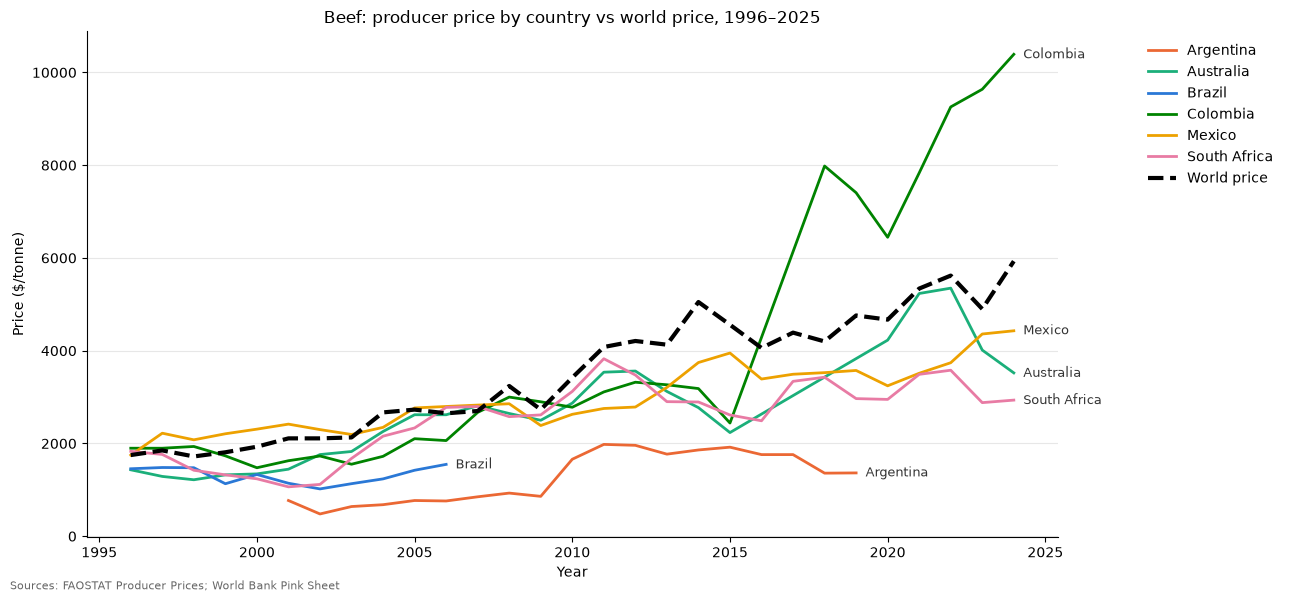

In [48]:
couleurs = {
    "Brazil": "#2a78d6",
    "Argentina": "#eb6834",
    "Australia": "#1baf7a",
    "Mexico": "#eda100",
    "South Africa": "#e87ba4",
    "Colombia": "#008300",
}

fig, ax = plt.subplots(figsize=(13, 6))

for p in sorted(cattle["Area"].unique()):
    d = cattle[cattle["Area"] == p].sort_values("Year")
    c = couleurs.get(p, "#999999")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=2, label=p)
    ax.text(d["Year"].iloc[-1] + 0.3, d["Value"].iloc[-1], p, color="#333333", fontsize=9, va="center")

monde = cattle.dropna(subset=["World price"]).drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, linestyle="--", label="World price")

ax.set_title("Beef: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, bbox_to_anchor=(1.08, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()


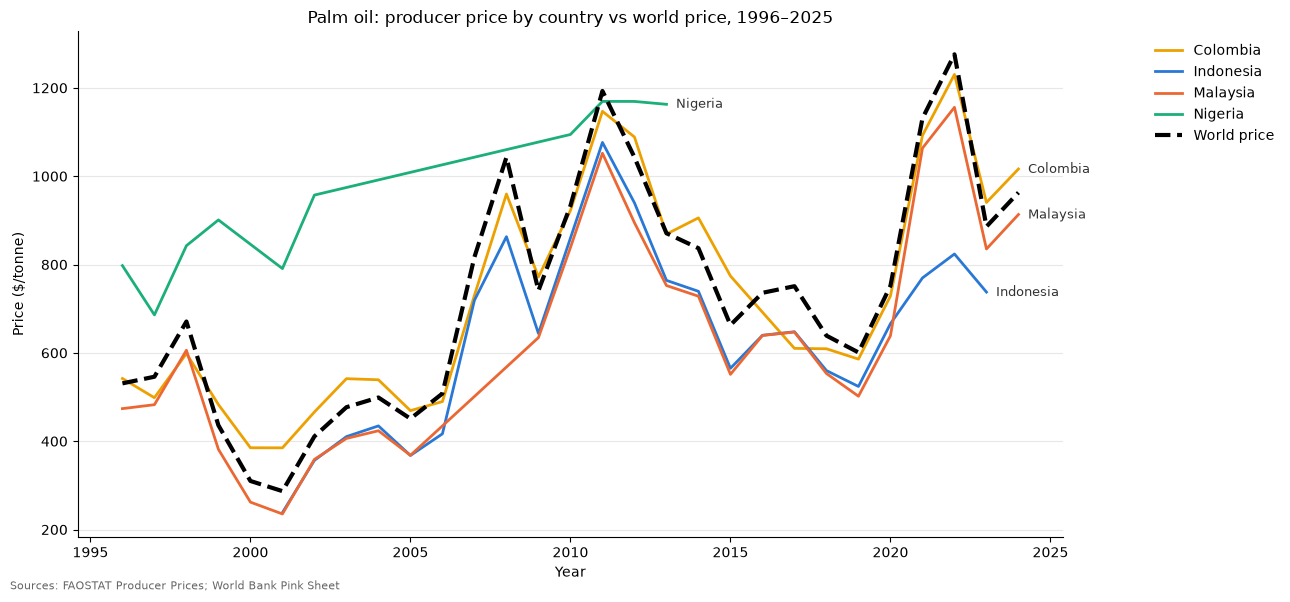

In [49]:
couleurs = {
    "Indonesia": "#2a78d6",
    "Malaysia": "#eb6834",
    "Thailand": "#e87ba4",
    "Nigeria": "#1baf7a",
    "Colombia": "#eda100",
}

fig, ax = plt.subplots(figsize=(13, 6))

for p in sorted(palm_oil["Area"].unique()):
    d = palm_oil[palm_oil["Area"] == p].sort_values("Year")
    c = couleurs.get(p, "#999999")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=2, label=p)
    ax.text(d["Year"].iloc[-1] + 0.3, d["Value"].iloc[-1], p, color="#333333", fontsize=9, va="center")

monde = palm_oil.dropna(subset=["World price"]).drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["World price"], color="black", linewidth=3, linestyle="--", label="World price")

ax.set_title("Palm oil: producer price by country vs world price, 1996–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/tonne)")
ax.legend(frameon=False, bbox_to_anchor=(1.08, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_FAO)
plt.tight_layout()
plt.show()


In [50]:
soy.head()

,Area,ISO3,Item,Year,Unit,Value,World price
0,Argentina,ARG,Soya beans,1996,USD,272.1,305
1,Argentina,ARG,Soya beans,1997,USD,291.1,295
2,Argentina,ARG,Soya beans,1998,USD,212.1,243
3,Argentina,ARG,Soya beans,1999,USD,167.1,202
4,Argentina,ARG,Soya beans,2000,USD,180.1,212


In [51]:
cattle.head()

,Area,ISO3,Item,Year,Unit,Value,World price
0,Australia,AUS,"Meat of cattle with the bone, fresh or chilled",1996,USD,1432.1,1750.0
1,Australia,AUS,"Meat of cattle with the bone, fresh or chilled",1997,USD,1289.2,1850.0
2,Australia,AUS,"Meat of cattle with the bone, fresh or chilled",1998,USD,1217.5,1720.0
3,Australia,AUS,"Meat of cattle with the bone, fresh or chilled",1999,USD,1323.3,1810.0
4,Australia,AUS,"Meat of cattle with the bone, fresh or chilled",2000,USD,1343.9,1930.0


In [52]:
palm_oil.head()

,Area,ISO3,Item,Year,Unit,Value,World price
0,Colombia,COL,Palm oil,1996,USD,542.0,531
1,Colombia,COL,Palm oil,1997,USD,498.5,546
2,Colombia,COL,Palm oil,1998,USD,598.4,671
3,Colombia,COL,Palm oil,1999,USD,483.0,436
4,Colombia,COL,Palm oil,2000,USD,385.2,310


# Building X: the price shock

For each country *i* and year *t*:

$$X_{it} = \sum_{c \in \{\text{beef, palm oil, soybeans}\}} \log(1 + E_{ic}) \times \tilde p_{ct}$$

- $E_{ic}$, **exposure** of country *i* to commodity *c*: value of its production in 1996–2000 (before our sample starts) divided by its forest area in 2000, in USD per hectare of forest.
- $\tilde p_{ct}$, **relative price**: log real world price minus its 1996–2000 average.
- We use the shock of the **previous year** ($X_{i,t-1}$), because clearing land takes time.

*Inputs:* `exposure_weights.csv` (baseline production value by country and commodity), `deforestation_panel.csv` (forest area in 2000 and tree cover loss), `commodity_prices_annual.csv` (Pink Sheet real prices).

In [53]:
weights = pd.read_csv(BASE_URL + "processed/exposure_weights.csv")
defor = pd.read_csv(BASE_URL + "processed/deforestation_panel.csv")
prices = pd.read_csv(BASE_URL + "processed/commodity_prices_annual.csv")

BASELINE = (1996, 2000)
COMMODITIES = ["Beef", "Palm oil", "Soybeans"]

print("Deforestation panel:", defor.shape, "|", defor["iso3"].nunique(), "countries,", defor["year"].min(), "-", defor["year"].max())

Deforestation panel: (1575, 11) | 63 countries, 2001 - 2025


### Exposure

Value of the 1996–2000 production (`value_base_usd`: average production × average real world price) divided by the forest area in 2000 (`extent_2000_ha`), for each crop separately.

South Sudan only exists since 2011, so it has no production before 2000: we drop it.

In [54]:
forest_2000 = defor[["iso3", "extent_2000_ha"]].drop_duplicates()

expo = weights[["iso3", "country", "commodity", "value_base_usd"]].merge(forest_2000, on="iso3")
expo = expo[expo["iso3"] != "SSD"]
expo["exposure"] = expo["value_base_usd"] / expo["extent_2000_ha"]

assert expo["exposure"].notna().all()
print(expo["iso3"].nunique(), "countries")
expo.pivot(index="country", columns="commodity", values="exposure").round(1).sort_values("Palm oil", ascending=False).head(10)

62 countries


commodity,Beef,Palm oil,Soybeans
country,,,
Malaysia,1.2,190.4,0.0
Nigeria,62.5,50.0,11.5
Indonesia,5.2,21.6,2.4
Costa Rica,47.8,16.8,0.0
Thailand,28.1,14.7,4.9
Côte d'Ivoire,3.1,10.9,0.1
Ghana,6.7,8.6,0.0
Ecuador,18.3,6.8,0.8
Honduras,16.7,6.6,0.2


A few countries have a very large exposure (much production on little forest), which would drive the results. We therefore use $\log(1 + E)$: it keeps the order between countries, compresses the extreme values and stays at 0 for countries that do not produce the crop.

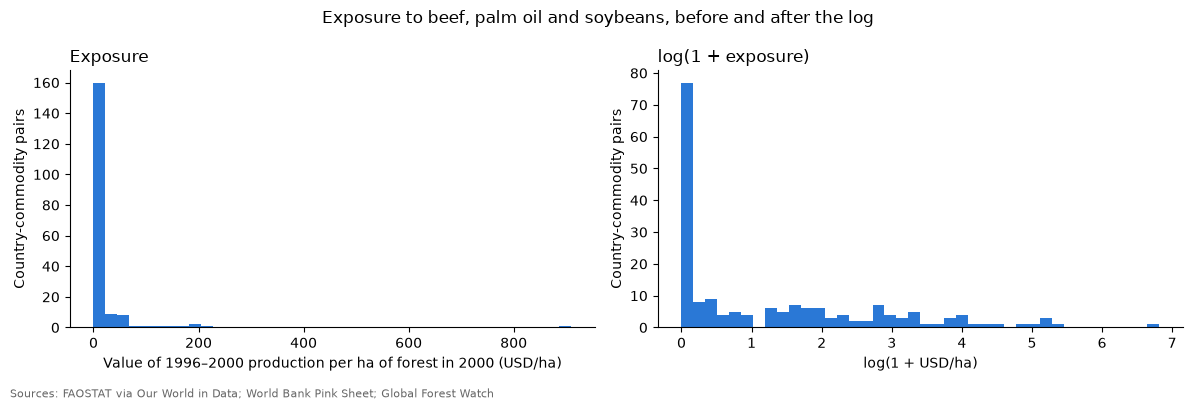

In [55]:
expo["log_exposure"] = np.log1p(expo["exposure"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(expo["exposure"], bins=40, color="#2a78d6")
axes[0].set_title("Exposure", loc="left")
axes[0].set_xlabel("Value of 1996–2000 production per ha of forest in 2000 (USD/ha)")
axes[1].hist(expo["log_exposure"], bins=40, color="#2a78d6")
axes[1].set_title("log(1 + exposure)", loc="left")
axes[1].set_xlabel("log(1 + USD/ha)")
for ax in axes:
    ax.set_ylabel("Country-commodity pairs")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Exposure to beef, palm oil and soybeans, before and after the log")
add_source(fig, "Sources: FAOSTAT via Our World in Data; World Bank Pink Sheet; Global Forest Watch")
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### Relative price

Log real world price minus its 1996–2000 average. It is 0 when the price is at its baseline level and 0.1 when it is about 10% higher. The unit of the price ($/kg or $/mt) drops out.

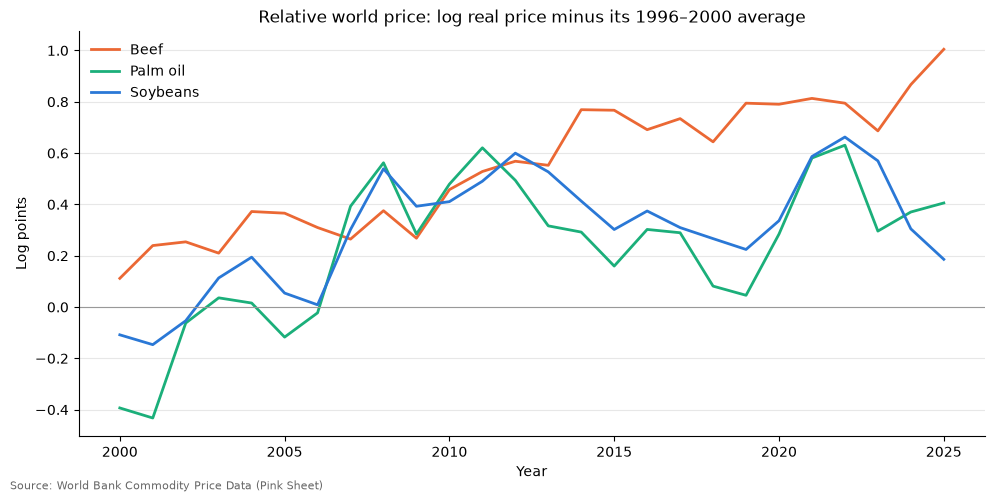

In [56]:
p = prices[prices["commodity"].isin(COMMODITIES)][["commodity", "year", "log_price_real"]].copy()
base = p[p["year"].between(*BASELINE)].groupby("commodity")["log_price_real"].mean()
p["rel_price"] = p["log_price_real"] - p["commodity"].map(base)

# from 2000, so that the 2001 shock can be lagged
p = p[p["year"].between(2000, defor["year"].max())]

fig, ax = plt.subplots(figsize=(10, 5))
for c, col in zip(COMMODITIES, ["#eb6834", "#1baf7a", "#2a78d6"]):
    d = p[p["commodity"] == c]
    ax.plot(d["year"], d["rel_price"], color=col, linewidth=2, label=c)
ax.axhline(0, color="#999999", linewidth=0.8)
ax.set_title("Relative world price: log real price minus its 1996–2000 average")
ax.set_xlabel("Year")
ax.set_ylabel("Log points")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, SOURCE_PS)
plt.tight_layout()
plt.show()

### Shock, lag and merge

Shock = log exposure × relative price, summed over the 3 crops. Then we lag it by one year within each country and merge it with the deforestation panel.

In [57]:
shock = expo[["iso3", "commodity", "log_exposure"]].merge(p[["commodity", "year", "rel_price"]], on="commodity")
shock["contrib"] = shock["log_exposure"] * shock["rel_price"]
shock = (shock.groupby(["iso3", "year"])["contrib"].sum()
              .rename("shock").reset_index()
              .sort_values(["iso3", "year"]))

# every country has all years 2000-2025, so shift(1) is the previous year
assert (shock.groupby("iso3")["year"].diff().dropna() == 1).all()
shock["shock_lag1"] = shock.groupby("iso3")["shock"].shift(1)
shock.head()

,iso3,year,shock,shock_lag1
0,AGO,2000,-0.006831,NaN
1,AGO,2001,0.160634,-0.006831
2,AGO,2002,0.339528,0.160634
3,AGO,2003,0.318587,0.339528
4,AGO,2004,0.544062,0.318587


In [58]:
panel = (defor[defor["iso3"] != "SSD"]
         .merge(shock, on=["iso3", "year"], how="left")
         .sort_values(["iso3", "year"])
         .reset_index(drop=True))

print("Rows:", len(panel), "| countries:", panel["iso3"].nunique(), "|", panel["year"].min(), "-", panel["year"].max())
assert len(panel) == (defor["iso3"] != "SSD").sum()
assert panel[["shock", "shock_lag1"]].notna().all().all()

# written locally, then pushed to GitHub
panel.to_csv("../../data/processed/shock_panel.csv", index=False)
panel.head()

Rows: 1550 | countries: 62 | 2001 - 2025


,iso3,country,region,year,extent_2000_ha,loss_ha,loss_rate,log_loss_rate,agri_loss_ha,agri_loss_rate,log_agri_loss_rate,shock,shock_lag1
0,AGO,Angola,Africa,2001,55276135,101219,0.183115,-1.697640,57200,0.103480,-2.268372,0.160634,-0.006831
1,AGO,Angola,Africa,2002,55276135,61008,0.110370,-2.203921,35899,0.064945,-2.734217,0.339528,0.160634
2,AGO,Angola,Africa,2003,55276135,52464,0.094913,-2.354799,30032,0.054331,-2.912663,0.318587,0.339528
3,AGO,Angola,Africa,2004,55276135,71271,0.128936,-2.048437,47671,0.086242,-2.450603,0.544062,0.318587
4,AGO,Angola,Africa,2005,55276135,93437,0.169037,-1.777639,61015,0.110382,-2.203807,0.477739,0.544062


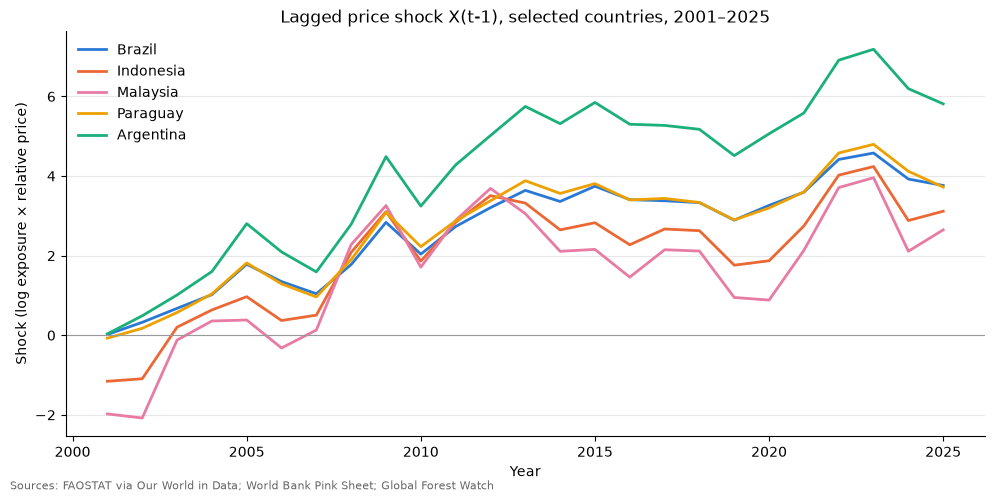

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))
for iso, col in zip(["BRA", "IDN", "MYS", "PRY", "ARG"], ["#2a78d6", "#eb6834", "#e87ba4", "#eda100", "#1baf7a"]):
    d = panel[panel["iso3"] == iso]
    ax.plot(d["year"], d["shock_lag1"], color=col, linewidth=2, label=d["country"].iloc[0])
ax.axhline(0, color="#999999", linewidth=0.8)
ax.set_title("Lagged price shock X(t-1), selected countries, 2001–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Shock (log exposure × relative price)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Sources: FAOSTAT via Our World in Data; World Bank Pink Sheet; Global Forest Watch")
plt.tight_layout()
plt.show()